# ABSA – PhoBERT + BiLSTM + Aspect-Aware Attention (Improved)

**Các cải tiến so với baseline:**
1. `MAX_LEN` 64 → 128
2. **Focal Loss** thay CrossEntropyLoss (xử lý mất cân bằng tốt hơn)
3. **Opinion Phrase Span Supervision** – dùng `opinion_phrase` trong data để dạy Attention attend đúng vùng
4. **Data Augmentation** cho minority aspects (synonym shuffle + random swap)
5. **Layer-wise LR Decay** cho PhoBERT encoder
6. Giữ nguyên: Bi-LSTM, HighwayNetwork, AspectAwareAttention, Stratified Split, Grad Clipping, Warmup Scheduler

SEED=42 | Device=cuda
MAX_LEN=128 | EPOCHS=20 | PATIENCE=5
Span=True | Oversample=True | LayerwiseLR=True | MultiDropout=True
Loaded 4762 reviews | 14 aspects: ['am_thanh', 'bao_hanh', 'camera', 'dich_vu', 'gia_tri', 'giao_hang', 'hieu_nang', 'ket_noi', 'man_hinh', 'phu_kien', 'pin', 'pin_sac', 'thiet_ke', 'tong_the']
Split: Train=3333 | Val=714 | Test=715
  Minority aspects (<200): {'phu_kien', 'am_thanh', 'ket_noi', 'pin_sac', 'camera', 'man_hinh', 'pin'}
  Counts: {'am_thanh': 27, 'camera': 130, 'ket_noi': 52, 'man_hinh': 123, 'phu_kien': 103, 'pin': 147, 'pin_sac': 28}
  Added 906 oversampled copies (no text modification)
After oversampling: Train=4239


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch 10/20 | Train Loss:0.9641 Acc:0.9938 F1:0.9784
             | Val   Loss:1.1660 Acc:0.9545 F1:0.7451
  >> Saved Best Model (Val F1 = 0.7451)


Epoch 11/20 | Train Loss:0.9574 Acc:0.9950 F1:0.9847
             | Val   Loss:1.1688 Acc:0.9508 F1:0.7374


Epoch 12/20 | Train Loss:0.9520 Acc:0.9964 F1:0.9894
             | Val   Loss:1.1709 Acc:0.9513 F1:0.7324


Epoch 14/20 | Train Loss:0.9429 Acc:0.9984 F1:0.9949
             | Val   Loss:1.1755 Acc:0.9532 F1:0.7368


Epoch 15/20 | Train Loss:0.9408 Acc:0.9985 F1:0.9952
             | Val   Loss:1.1732 Acc:0.9524 F1:0.7307
  >> Early stopping at epoch 15 (no improvement for 5 epochs)

Training completed. Plotting history...


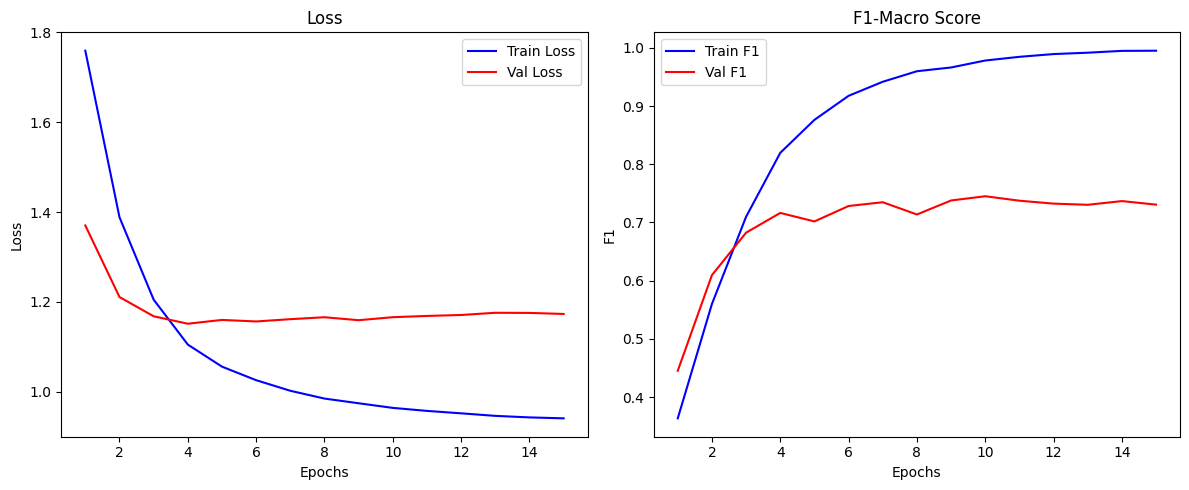


       FINAL EVALUATION ON TEST SET      


Test Loss: 1.1527 | Acc: 0.9579 | F1-Macro: 0.7537

              precision    recall  f1-score   support

        none       0.98      0.98      0.98      8336
    positive       0.91      0.90      0.90      1360
     neutral       0.43      0.41      0.42        80
    negative       0.69      0.73      0.71       234

    accuracy                           0.96     10010
   macro avg       0.75      0.75      0.75     10010
weighted avg       0.96      0.96      0.96     10010


         INFERENCE (TEST CASES)          

[Test Case 1]: Điện thoại thiết kế rất đẹp và sang trọng, chụp ảnh sắc nét, shop giao hàng hỏa tốc luôn. Rất đáng tiền!
  => camera          | 🟢 POS | Evidence: [chụp + ảnh + sắc]
  => gia_tri         | 🟢 POS | Evidence: [đáng + Rất + tiề]
  => giao_hang       | 🟢 POS | Evidence: [giao + hàng + a]
  => thiet_ke        | 🟢 POS | Evidence: [kế + rất + đẹp]

[Test Case 2]: Pin tụt nhanh kinh khủng, mới chơi game xíu đã nóng ran. Gọi điện bảo hành thì nhân viên trả lời

In [1]:
"""
ABSA Improved – Part 1: Config, Data, Model
Paste each section (separated by #===) into separate notebook cells.
"""

# === CELL 1: Imports ===
import random, os, math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer, get_cosine_schedule_with_warmup
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter, defaultdict

# === CELL 2: Config ===
DATA_FILE = "/kaggle/input/datasets/phantrihieu/absa-reviews-phone-on-shopee/absa_training_flat.jsonl"
MODEL_SAVE_PATH = "best_absa_improved.pth"
PHOBERT_VERSION = "vinai/phobert-base"
MAX_LEN = 128           # Baseline was 64 — Vietnamese reviews need more tokens
LSTM_HIDDEN_SIZE = 256
LSTM_LAYERS = 1
FREEZE_PHOBERT = False
BATCH_SIZE = 16
EPOCHS = 20             # More epochs + early stopping
LEARNING_RATE = 2e-5
LR_DECAY_FACTOR = 0.95  # Gentle layer-wise decay (baseline had none, failed attempt used 0.65)
LABEL_SMOOTHING = 0.1
DROPOUT_RATE = 0.4
MULTI_SAMPLE_K = 8      # Multi-sample dropout: apply dropout K times, average losses
SPAN_LOSS_WEIGHT = 0.15   # KL divergence weight for attention guidance
OVERSAMPLE_THRESHOLD = 200
PATIENCE = 5             # Early stopping patience

# Feature flags
ENABLE_SPAN_SUPERVISION = True
ENABLE_OVERSAMPLING = True
ENABLE_LAYERWISE_LR = True
ENABLE_MULTI_DROPOUT = True

SENTIMENT_MAP = {'none': 0, 'positive': 1, 'neutral': 2, 'negative': 3}
ID_TO_SENTIMENT = {v: k for k, v in SENTIMENT_MAP.items()}
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

def set_seed(s):
    random.seed(s); os.environ['PYTHONHASHSEED'] = str(s); np.random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# === CELL 3: Data Loading + Oversampling ===
def load_and_group_data(file_path):
    df = pd.read_json(file_path, lines=True)
    unique_aspects = sorted(df['aspect'].dropna().unique().tolist())

    def aggregate(x):
        sentiments = dict(zip(x['aspect'], x['sentiment']))
        phrases = defaultdict(list)
        for _, row in x.iterrows():
            if pd.notna(row.get('opinion_phrase', None)) and row['opinion_phrase']:
                phrases[row['aspect']].append(str(row['opinion_phrase']))
        return pd.Series({'sentiments': sentiments, 'phrases': dict(phrases)})

    grouped = df.groupby('text').apply(aggregate, include_groups=False).reset_index()
    texts = grouped['text'].tolist()
    aspect_dicts = grouped['sentiments'].tolist()
    phrase_dicts = grouped['phrases'].tolist()

    labels = []
    for d in aspect_dicts:
        label_row = [SENTIMENT_MAP.get(d.get(asp, 'none'), 0) for asp in unique_aspects]
        labels.append(label_row)

    return texts, labels, phrase_dicts, unique_aspects


def oversample_minority(train_texts, train_labels, train_phrases, unique_aspects,
                        threshold=OVERSAMPLE_THRESHOLD):
    """Simple oversampling: DUPLICATE original samples (no text corruption)."""
    aspect_counts = Counter()
    for label_row in train_labels:
        for i, asp in enumerate(unique_aspects):
            if label_row[i] != 0:
                aspect_counts[asp] += 1

    minority = {a for a, c in aspect_counts.items() if c < threshold}
    print(f"  Minority aspects (<{threshold}): {minority}")
    print(f"  Counts: { {a: aspect_counts[a] for a in sorted(minority)} }")

    # For each minority sample, figure out how many times to duplicate
    aug_t, aug_l, aug_p = [], [], []
    for text, lbl, phr in zip(train_texts, train_labels, train_phrases):
        has_min = any(lbl[i] != 0 and unique_aspects[i] in minority for i in range(len(unique_aspects)))
        if has_min:
            # Duplicate 2 times (total 3 copies including original)
            for _ in range(2):
                aug_t.append(text)
                aug_l.append(lbl)
                aug_p.append(phr)

    print(f"  Added {len(aug_t)} oversampled copies (no text modification)")
    return train_texts + aug_t, train_labels + aug_l, train_phrases + aug_p


# === CELL 4: Span Mask Builder + Dataset ===
def find_subseq(seq, subseq):
    n, m = len(seq), len(subseq)
    if m == 0 or m > n:
        return []
    starts = []
    for i in range(n - m + 1):
        if seq[i:i+m] == subseq:
            starts.append(i)
    return starts


def build_span_mask(text, phrase_list, tokenizer, max_len):
    mask = torch.zeros(max_len)
    if not phrase_list:
        return mask
    sent_ids = tokenizer.encode(text, add_special_tokens=True, max_length=max_len, truncation=True)
    for phrase in phrase_list:
        phrase = str(phrase).strip()
        if not phrase:
            continue
        phrase_ids = tokenizer.encode(phrase, add_special_tokens=False)
        if not phrase_ids:
            continue
        for start in find_subseq(sent_ids, phrase_ids):
            for offset in range(len(phrase_ids)):
                if start + offset < max_len:
                    mask[start + offset] = 1.0
    return mask


class ABSADataset(Dataset):
    def __init__(self, texts, labels, phrase_dicts, unique_aspects, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.phrase_dicts = phrase_dicts
        self.unique_aspects = unique_aspects
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]
        phrase_dict = self.phrase_dicts[item]

        encoding = self.tokenizer(
            text, add_special_tokens=True, max_length=self.max_len,
            padding='max_length', truncation=True,
            return_attention_mask=True, return_tensors='pt',
        )

        span_masks = []
        for asp in self.unique_aspects:
            phrases = phrase_dict.get(asp, [])
            span_masks.append(build_span_mask(text, phrases, self.tokenizer, self.max_len))
        span_masks = torch.stack(span_masks, dim=0)

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long),
            'span_masks': span_masks,
        }


# === CELL 5: Model Architecture ===
class HighwayNetwork(nn.Module):
    def __init__(self, size):
        super().__init__()
        self.transform = nn.Linear(size, size)
        self.gate = nn.Linear(size, size)

    def forward(self, x):
        t = torch.sigmoid(self.gate(x))
        h = torch.relu(self.transform(x))
        return t * h + (1.0 - t) * x


class AspectAwareAttention(nn.Module):
    """Additive attention that learns aspect-specific focus on token sequence."""
    def __init__(self, hidden_size, aspect_dim):
        super().__init__()
        self.W_h = nn.Linear(hidden_size, hidden_size)
        self.W_a = nn.Linear(aspect_dim, hidden_size)
        self.v = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, lstm_out, aspect_embed):
        H = self.W_h(lstm_out).unsqueeze(1)
        A = self.W_a(aspect_embed).unsqueeze(2)
        M = torch.tanh(H + A)
        scores = self.v(M).squeeze(-1)
        attn_weights = torch.softmax(scores, dim=2)
        context = torch.bmm(attn_weights, lstm_out)
        return context, attn_weights


class PhoBERT_BiLSTM_ABSA(nn.Module):
    """
    PhoBERT + BiLSTM + AspectAwareAttention + Highway + Multi-Sample Dropout.
    Attention mechanism learns which tokens matter for each aspect.
    Span supervision (KL divergence) guides attention toward opinion phrases.
    """
    def __init__(self, num_aspects, num_sentiments=4, dropout_rate=DROPOUT_RATE,
                 multi_sample_k=MULTI_SAMPLE_K):
        super().__init__()
        self.num_aspects = num_aspects
        self.multi_sample_k = multi_sample_k if ENABLE_MULTI_DROPOUT else 1

        self.phobert = AutoModel.from_pretrained(PHOBERT_VERSION)
        if FREEZE_PHOBERT:
            for p in self.phobert.parameters():
                p.requires_grad = False

        self.bilstm = nn.LSTM(768, LSTM_HIDDEN_SIZE, LSTM_LAYERS,
                              bidirectional=True, batch_first=True)
        hs = LSTM_HIDDEN_SIZE * 2

        self.aspect_embeddings = nn.Embedding(num_aspects, hs)
        self.attention = AspectAwareAttention(hs, hs)
        self.highway = HighwayNetwork(hs)

        # Multi-sample dropout: K independent dropout layers
        self.dropouts = nn.ModuleList([nn.Dropout(dropout_rate) for _ in range(self.multi_sample_k)])
        self.classifier = nn.Linear(hs, num_sentiments)

    def forward(self, input_ids, attention_mask, return_attention=False):
        phobert_out = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        lstm_out, _ = self.bilstm(phobert_out.last_hidden_state)

        B = input_ids.size(0)
        aspect_ids = torch.arange(self.num_aspects).to(input_ids.device)
        aspect_embeds = self.aspect_embeddings(aspect_ids).unsqueeze(0).expand(B, -1, -1)

        attn_out, attn_weights = self.attention(lstm_out, aspect_embeds)
        highway_out = self.highway(attn_out)

        if self.training and self.multi_sample_k > 1:
            # Multi-sample dropout: average logits from K dropout passes
            logits_list = [self.classifier(drop(highway_out)) for drop in self.dropouts]
            avg_logits = sum(logits_list) / len(logits_list)
            if return_attention:
                return logits_list, attn_weights
            return logits_list
        else:
            logits = self.classifier(self.dropouts[0](highway_out))
            if return_attention:
                return logits, attn_weights
            return logits

"""
ABSA Improved – Part 2: Training Functions + Main Program
Paste each section (separated by #===) into separate notebook cells.
"""

# === CELL 6: Span Loss + Train/Eval Functions ===
def compute_span_loss_kl(attn_weights, span_masks):
    """KL divergence to guide attention toward opinion phrase tokens."""
    span_sum = span_masks.sum(dim=2, keepdim=True).clamp(min=1e-9)
    target_dist = span_masks / span_sum
    has_span = (span_masks.sum(dim=2) > 0).float()

    log_attn = torch.log(attn_weights.clamp(min=1e-9))
    log_target = torch.log(target_dist.clamp(min=1e-9))
    kl = (target_dist * (log_target - log_attn)).sum(dim=2)
    kl = kl * has_span

    num_valid = has_span.sum().clamp(min=1)
    return kl.sum() / num_valid


def train_epoch(model, data_loader, loss_fn, optimizer, scheduler, device, epoch, total_epochs):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    loop = tqdm(data_loader, leave=False, bar_format="{l_bar}{bar:30}{r_bar}")
    loop.set_description(f"Epoch [{epoch}/{total_epochs}] Train")

    for batch in loop:
        input_ids = batch['input_ids'].to(device)
        attn_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        span_masks = batch['span_masks'].to(device)

        optimizer.zero_grad()

        result = model(input_ids, attn_mask, return_attention=True)

        if isinstance(result[0], list):
            # Multi-sample dropout: result = (logits_list, attn_weights)
            logits_list, attn_weights = result
            labels_flat = labels.view(-1)
            # Average loss over K dropout samples
            main_loss = sum(
                loss_fn(l.view(-1, l.size(-1)), labels_flat) for l in logits_list
            ) / len(logits_list)
            avg_logits = sum(logits_list) / len(logits_list)
            logits_flat = avg_logits.view(-1, avg_logits.size(-1))
        else:
            logits, attn_weights = result
            logits_flat = logits.view(-1, logits.size(-1))
            labels_flat = labels.view(-1)
            main_loss = loss_fn(logits_flat, labels_flat)

        if ENABLE_SPAN_SUPERVISION:
            span_loss = compute_span_loss_kl(attn_weights, span_masks)
            loss = main_loss + SPAN_LOSS_WEIGHT * span_loss
        else:
            loss = main_loss

        total_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        preds = torch.argmax(logits_flat, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels_flat.cpu().numpy())
        loop.set_postfix(loss=f"{loss.item():.4f}")

    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / len(data_loader), acc, f1


def eval_model(model, data_loader, loss_fn, device, phase="Val", epoch=None, total_epochs=None):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    loop = tqdm(data_loader, leave=False, bar_format="{l_bar}{bar:30}{r_bar}")
    desc = f"Epoch [{epoch}/{total_epochs}] {phase}" if epoch else phase
    loop.set_description(desc)

    with torch.no_grad():
        for batch in loop:
            input_ids = batch['input_ids'].to(device)
            attn_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attn_mask)
            if isinstance(logits, list):
                logits = sum(logits) / len(logits)
            logits_flat = logits.view(-1, logits.size(-1))
            labels_flat = labels.view(-1)

            loss = loss_fn(logits_flat, labels_flat)
            total_loss += loss.item()

            preds = torch.argmax(logits_flat, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels_flat.cpu().numpy())
            loop.set_postfix(loss=f"{loss.item():.4f}")

    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / len(data_loader), acc, f1, all_preds, all_labels


def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 'r-', label='Val Loss')
    plt.title('Loss'); plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_f1'], 'b-', label='Train F1')
    plt.plot(epochs, history['val_f1'], 'r-', label='Val F1')
    plt.title('F1-Macro Score'); plt.xlabel('Epochs'); plt.ylabel('F1'); plt.legend()
    plt.tight_layout(); plt.show()


# === CELL 7: Layer-wise LR Decay Helper ===
def get_layerwise_params(model, base_lr=LEARNING_RATE, decay=LR_DECAY_FACTOR):
    param_groups = []
    custom_head_params, phobert_other_params = [], []
    phobert_layer_params = {i: [] for i in range(12)}

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if 'phobert' not in name:
            custom_head_params.append(param)
        elif 'encoder.layer.' in name:
            layer_idx = int(name.split('encoder.layer.')[1].split('.')[0])
            phobert_layer_params[layer_idx].append(param)
        else:
            phobert_other_params.append(param)

    param_groups.append({'params': custom_head_params, 'lr': 1e-3})
    for i in range(11, -1, -1):
        depth = 11 - i
        lr = base_lr * (decay ** depth)
        if phobert_layer_params[i]:
            param_groups.append({'params': phobert_layer_params[i], 'lr': lr})
    if phobert_other_params:
        param_groups.append({'params': phobert_other_params, 'lr': base_lr * (decay ** 12)})
    return param_groups


# === CELL 8: Inference Function ===
def predict_sentiment(text, model, tokenizer, unique_aspects, device, max_len=MAX_LEN):
    model.eval()
    encoding = tokenizer(
        text, add_special_tokens=True, max_length=max_len,
        padding='max_length', truncation=True,
        return_attention_mask=True, return_tensors='pt'
    )
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        logits, attn_weights = model(input_ids, attention_mask, return_attention=True)
        if isinstance(logits, list):
            logits = sum(logits) / len(logits)
        preds = torch.argmax(logits, dim=2).squeeze(0)
        attn_weights = attn_weights.squeeze(0)

    tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze(0))
    result = {}
    for i, asp in enumerate(unique_aspects):
        sid = preds[i].item()
        if sid != 0:
            w = attn_weights[i].cpu().numpy()
            top_idx = w.argsort()[-3:][::-1]
            evidence = []
            for idx in top_idx:
                if tokens[idx] not in ['<s>', '</s>', '<pad>']:
                    evidence.append(tokens[idx].replace('_', ' ').replace('@@', ''))
            result[asp] = {
                'sentiment': ID_TO_SENTIMENT[sid],
                'evidence': " + ".join(evidence)
            }
    return result


# === CELL 9: Main Program ===
if __name__ == "__main__":
    set_seed(SEED)
    print(f"SEED={SEED} | Device={DEVICE}")
    print(f"MAX_LEN={MAX_LEN} | EPOCHS={EPOCHS} | PATIENCE={PATIENCE}")
    print(f"Span={ENABLE_SPAN_SUPERVISION} | Oversample={ENABLE_OVERSAMPLING} | "
          f"LayerwiseLR={ENABLE_LAYERWISE_LR} | MultiDropout={ENABLE_MULTI_DROPOUT}")

    # 1. Load data
    texts, labels, phrase_dicts, unique_aspects = load_and_group_data(DATA_FILE)
    print(f"Loaded {len(texts)} reviews | {len(unique_aspects)} aspects: {unique_aspects}")

    # 2. Stratified split
    str_labels = ["_".join(map(str, lbl)) for lbl in labels]
    label_counts = Counter(str_labels)
    safe_labels = [l if label_counts[l] >= 2 else "rare" for l in str_labels]

    train_texts, temp_texts, train_labels, temp_labels, train_phrases, temp_phrases, _, temp_safe = \
        train_test_split(texts, labels, phrase_dicts, safe_labels,
                         test_size=0.3, random_state=SEED, stratify=safe_labels)

    tc = Counter(temp_safe)
    temp_strat = [l if tc[l] >= 2 else "rare" for l in temp_safe]
    val_texts, test_texts, val_labels, test_labels, val_phrases, test_phrases = \
        train_test_split(temp_texts, temp_labels, temp_phrases,
                         test_size=0.5, random_state=SEED, stratify=temp_strat)

    print(f"Split: Train={len(train_texts)} | Val={len(val_texts)} | Test={len(test_texts)}")

    # 3. Oversampling (no text corruption — just duplicates)
    if ENABLE_OVERSAMPLING:
        train_texts, train_labels, train_phrases = oversample_minority(
            train_texts, train_labels, train_phrases, unique_aspects)
        print(f"After oversampling: Train={len(train_texts)}")

    # 4. Tokenizer + DataLoader
    tokenizer = AutoTokenizer.from_pretrained(PHOBERT_VERSION)
    train_ds = ABSADataset(train_texts, train_labels, train_phrases, unique_aspects, tokenizer, MAX_LEN)
    val_ds = ABSADataset(val_texts, val_labels, val_phrases, unique_aspects, tokenizer, MAX_LEN)
    test_ds = ABSADataset(test_texts, test_labels, test_phrases, unique_aspects, tokenizer, MAX_LEN)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)

    # 5. Model
    model = PhoBERT_BiLSTM_ABSA(num_aspects=len(unique_aspects)).to(DEVICE)

    # 6. Loss (same proven recipe as baseline)
    flat_labels = np.array(train_labels).flatten()
    classes = np.unique(flat_labels)
    weights = compute_class_weight('balanced', classes=classes, y=flat_labels)
    cw = torch.tensor(np.sqrt(weights), dtype=torch.float).to(DEVICE)
    print(f"Class weights (sqrt-balanced): {cw}")
    loss_fn = nn.CrossEntropyLoss(weight=cw, label_smoothing=LABEL_SMOOTHING)

    # 7. Optimizer (layer-wise LR decay)
    if ENABLE_LAYERWISE_LR:
        param_groups = get_layerwise_params(model)
        optimizer = torch.optim.AdamW(param_groups, weight_decay=0.01)
        print(f"Layer-wise LR decay={LR_DECAY_FACTOR} | {len(param_groups)} param groups")
    else:
        pb_params = [p for n, p in model.named_parameters() if 'phobert' in n]
        hd_params = [p for n, p in model.named_parameters() if 'phobert' not in n]
        optimizer = torch.optim.AdamW([
            {'params': pb_params, 'lr': LEARNING_RATE},
            {'params': hd_params, 'lr': 1e-3}
        ], weight_decay=0.01)

    # 8. Cosine annealing scheduler with warmup
    total_steps = len(train_loader) * EPOCHS
    warmup_steps = int(0.1 * total_steps)
    scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    # 9. Training loop with early stopping
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [],
               'train_f1': [], 'val_f1': []}
    best_val_f1 = 0
    no_improve = 0

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc, tr_f1 = train_epoch(
            model, train_loader, loss_fn, optimizer, scheduler, DEVICE, epoch, EPOCHS)
        vl_loss, vl_acc, vl_f1, _, _ = eval_model(
            model, val_loader, loss_fn, DEVICE, "Val", epoch, EPOCHS)

        history['train_loss'].append(tr_loss); history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc);   history['val_acc'].append(vl_acc)
        history['train_f1'].append(tr_f1);     history['val_f1'].append(vl_f1)

        print(f"Epoch {epoch:02d}/{EPOCHS} | Train Loss:{tr_loss:.4f} Acc:{tr_acc:.4f} F1:{tr_f1:.4f}")
        print(f"             | Val   Loss:{vl_loss:.4f} Acc:{vl_acc:.4f} F1:{vl_f1:.4f}")

        if vl_f1 > best_val_f1:
            best_val_f1 = vl_f1
            no_improve = 0
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
            print(f"  >> Saved Best Model (Val F1 = {vl_f1:.4f})")
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f"  >> Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
                break

    print("\nTraining completed. Plotting history...")
    plot_history(history)

    # 10. Test evaluation
    print("\n=========================================")
    print("       FINAL EVALUATION ON TEST SET      ")
    print("=========================================")
    model.load_state_dict(torch.load(MODEL_SAVE_PATH))
    te_loss, te_acc, te_f1, te_preds, te_labels_flat = eval_model(
        model, test_loader, loss_fn, DEVICE, "Test")
    print(f"Test Loss: {te_loss:.4f} | Acc: {te_acc:.4f} | F1-Macro: {te_f1:.4f}\n")
    target_names = [ID_TO_SENTIMENT.get(i, f"Class {i}") for i in range(4)]
    print(classification_report(te_labels_flat, te_preds, target_names=target_names, zero_division=0))

    # 11. Inference
    print("\n=========================================")
    print("         INFERENCE (TEST CASES)          ")
    print("=========================================")
    model.load_state_dict(torch.load(MODEL_SAVE_PATH))

    test_cases = [
        "Điện thoại thiết kế rất đẹp và sang trọng, chụp ảnh sắc nét, shop giao hàng hỏa tốc luôn. Rất đáng tiền!",
        "Pin tụt nhanh kinh khủng, mới chơi game xíu đã nóng ran. Gọi điện bảo hành thì nhân viên trả lời thái độ vô cùng lồi lõm, thất vọng thực sự.",
        "Máy cầm đầm tay, màn hình hiển thị khá ổn nhưng loa nghe hơi nhỏ. Giá cả như vậy thì cũng tạm chấp nhận được.",
        "Shipper nhiệt tình thân thiện.",
        "Nói chung là xài cũng được, không có gì nổi bật."
    ]

    for i, text in enumerate(test_cases, 1):
        print(f"\n[Test Case {i}]: {text}")
        preds = predict_sentiment(text, model, tokenizer, unique_aspects, DEVICE)
        if not preds:
            print("  => Không phát hiện khía cạnh nào (None).")
        else:
            for asp, data in preds.items():
                s = data['sentiment']
                e = data['evidence']
                tag = "🟢 POS" if s == 'positive' else ("🔴 NEG" if s == 'negative' else "🟡 NEU")
                print(f"  => {asp.ljust(15)} | {tag} | Evidence: [{e}]")
